In [1]:
# Install additional packages if needed

!pip install torch torchvision torchaudio --quiet
!pip install numpy pandas scikit-learn tqdm matplotlib seaborn --quiet

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import os
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Training utilities
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
import random

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
#Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

print("Random seeds initialized")

Random seeds initialized


In [4]:
#Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [5]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from pathlib import Path

# Experiment version selector
EXPERIMENT_VERSION = "v4"

# Base project directory in Google Drive
PROJECT_DIR = Path("/content/drive/MyDrive/crypto_trading_project")

# Dataset directory for this experiment
DATA_DIR = PROJECT_DIR / f"datasets_{EXPERIMENT_VERSION}"

train_path = DATA_DIR / "BTCUSDT_15m_train_windows_norm_v4.npz"
val_path   = DATA_DIR / "BTCUSDT_15m_val_windows_norm_v4.npz"
test_path  = DATA_DIR / "BTCUSDT_15m_test_windows_norm_v4.npz"
scaler_path = DATA_DIR / "BTCUSDT_15m_scaler_stats_v4.npz"

print("Experiment version:", EXPERIMENT_VERSION)
print("Dataset directory:", DATA_DIR)
print("Train path:", train_path)
print("Validation path:", val_path)
print("Test path:", test_path)
print("Scaler path:", scaler_path)

Experiment version: v4
Dataset directory: /content/drive/MyDrive/crypto_trading_project/datasets_v4
Train path: /content/drive/MyDrive/crypto_trading_project/datasets_v4/BTCUSDT_15m_train_windows_norm_v4.npz
Validation path: /content/drive/MyDrive/crypto_trading_project/datasets_v4/BTCUSDT_15m_val_windows_norm_v4.npz
Test path: /content/drive/MyDrive/crypto_trading_project/datasets_v4/BTCUSDT_15m_test_windows_norm_v4.npz
Scaler path: /content/drive/MyDrive/crypto_trading_project/datasets_v4/BTCUSDT_15m_scaler_stats_v4.npz


In [7]:
#Load NPZ Datasets
train_data = np.load(train_path)
val_data = np.load(val_path)
test_data = np.load(test_path)

X_train = train_data["X"]
y_train = train_data["y"]
train_time = train_data["end_time"]

X_val = val_data["X"]
y_val = val_data["y"]
val_time = val_data["end_time"]

X_test = test_data["X"]
y_test = test_data["y"]
test_time = test_data["end_time"]

print("Datasets loaded successfully")

Datasets loaded successfully


In [8]:
#Inspect Dataset Shapes
print("TRAIN")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nVALIDATION")
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTEST")
print("X:", X_test.shape)
print("y:", y_test.shape)

TRAIN
X: (80156, 96, 19)
y: (80156,)

VALIDATION
X: (21249, 96, 19)
y: (21249,)

TEST
X: (23371, 96, 19)
y: (23371,)


In [9]:
#Data Sanity Check
print("Feature example (first window, first timestep):")
print(X_train[0,0,:])

print("\nFirst label:", y_train[0])

print("\nClass balance (train):")
print("UP:", np.sum(y_train == 1))
print("DOWN:", np.sum(y_train == 0))

Feature example (first window, first timestep):
[ 0.05275084  1.7767928   0.05076624  0.20935486  0.05076624  0.30058256
  1.4660673  -1.665123    0.9623404   0.8480418   0.49217516  0.9850511
  0.15273306  0.22344619  0.15697654  0.97974026  0.11954003  0.04931487
  0.05859083]

First label: 1

Class balance (train):
UP: 41384
DOWN: 38772


In [10]:
# Training / data pipeline configuration
BATCH_SIZE = 128
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

NUM_FEATURES = X_train.shape[2]
SEQUENCE_LENGTH = X_train.shape[1]

print("Batch size:", BATCH_SIZE)
print("Num workers:", NUM_WORKERS)
print("Pin memory:", PIN_MEMORY)
print("Num features:", NUM_FEATURES)
print("Sequence length:", SEQUENCE_LENGTH)

Batch size: 128
Num workers: 2
Pin memory: True
Num features: 19
Sequence length: 96


In [11]:
#Define PyTorch Dataset
class CryptoSequenceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        """
        X shape: (samples, seq_len, features)
        y shape: (samples,)
        """
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]                 # shape: (256, 19)
        y = self.y[idx]                 # scalar

        # Convert to torch tensors
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        # TCN / Conv1D expects: (features, sequence_length)
        x = x.transpose(0, 1)           # shape: (19, 256)

        return x, y

In [12]:
#Creating dataset objects
train_dataset = CryptoSequenceDataset(X_train, y_train)
val_dataset = CryptoSequenceDataset(X_val, y_val)
test_dataset = CryptoSequenceDataset(X_test, y_test)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 80156
Validation dataset size: 21249
Test dataset size: 23371


In [13]:
#Inspect one dataset sample
x_sample, y_sample = train_dataset[0]

print("Single sample X shape:", x_sample.shape)   # expected: (19, 256)
print("Single sample y shape:", y_sample.shape)   # expected: scalar tensor
print("Single sample y value:", y_sample.item())

Single sample X shape: torch.Size([19, 96])
Single sample y shape: torch.Size([])
Single sample y value: 1.0


In [14]:
#Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("DataLoaders created successfully")

DataLoaders created successfully


In [15]:
#Inspect one batch from train loader
x_batch, y_batch = next(iter(train_loader))

print("Train batch X shape:", x_batch.shape)   # expected: (batch, 19, 256)
print("Train batch y shape:", y_batch.shape)   # expected: (batch,)
print("Train batch X dtype:", x_batch.dtype)
print("Train batch y dtype:", y_batch.dtype)

Train batch X shape: torch.Size([128, 19, 96])
Train batch y shape: torch.Size([128])
Train batch X dtype: torch.float32
Train batch y dtype: torch.float32


In [16]:
#GPU transfer sanity check
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

print("Batch moved to device successfully")
print("X device:", x_batch.device)
print("y device:", y_batch.device)

Batch moved to device successfully
X device: cuda:0
y device: cuda:0


In [17]:
# Training configuration
CONFIG = {
    "experiment_version": EXPERIMENT_VERSION,

    "input_channels": 19,
    "sequence_length": 96,
    "num_classes": 1,              # one logit for binary classification
    "channels": [32, 64, 64, 64, 64, 64],
    "kernel_size": 3,
    "dropout": 0.3,

    "batch_size": 128,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 50,
    "early_stopping_patience": 10,
    "grad_clip": 1.0,

    "checkpoint_every": 5,
    "random_seed": 42,
}

print(CONFIG)

{'experiment_version': 'v4', 'input_channels': 19, 'sequence_length': 96, 'num_classes': 1, 'channels': [32, 64, 64, 64, 64, 64], 'kernel_size': 3, 'dropout': 0.3, 'batch_size': 128, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'max_epochs': 50, 'early_stopping_patience': 10, 'grad_clip': 1.0, 'checkpoint_every': 5, 'random_seed': 42}


In [18]:
# Checkpoint directory for this experiment
CHECKPOINT_DIR = PROJECT_DIR / f"checkpoints_{EXPERIMENT_VERSION}"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = CHECKPOINT_DIR / "best_model.pt"
LAST_MODEL_PATH = CHECKPOINT_DIR / "last_model.pt"
HISTORY_PATH = CHECKPOINT_DIR / "training_history.csv"

print("Checkpoint directory:", CHECKPOINT_DIR)
print("Best model path:", BEST_MODEL_PATH)
print("Last model path:", LAST_MODEL_PATH)
print("History path:", HISTORY_PATH)

Checkpoint directory: /content/drive/MyDrive/crypto_trading_project/checkpoints_v4
Best model path: /content/drive/MyDrive/crypto_trading_project/checkpoints_v4/best_model.pt
Last model path: /content/drive/MyDrive/crypto_trading_project/checkpoints_v4/last_model.pt
History path: /content/drive/MyDrive/crypto_trading_project/checkpoints_v4/training_history.csv


In [19]:
#TCN building blocks
import torch.nn.utils.weight_norm as weight_norm

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = weight_norm(
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size,
                padding=padding,
                dilation=dilation
            )
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = weight_norm(
            nn.Conv1d(
                out_channels,
                out_channels,
                kernel_size,
                padding=padding,
                dilation=dilation
            )
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.relu1, self.dropout1,
            self.conv2, self.chomp2, self.relu2, self.dropout2
        )

        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) \
            if in_channels != out_channels else None

        self.final_relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        residual = x if self.downsample is None else self.downsample(x)
        return self.final_relu(out + residual)

In [20]:
#TCN model
class TCNClassifier(nn.Module):
    def __init__(self, input_channels, channels, kernel_size=3, dropout=0.2):
        super().__init__()

        layers = []
        in_channels = input_channels

        for i, out_channels in enumerate(channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout
                )
            )
            in_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.classifier = nn.Linear(channels[-1], 1)

    def forward(self, x):
        """
        x shape: (batch, features, seq_len)
        """
        features = self.tcn(x)              # (batch, channels, seq_len)
        last_timestep = features[:, :, -1]  # (batch, channels)
        logits = self.classifier(last_timestep).squeeze(-1)  # (batch,)
        return logits

In [21]:
#Instatiate model
model = TCNClassifier(
    input_channels=CONFIG["input_channels"],
    channels=CONFIG["channels"],
    kernel_size=CONFIG["kernel_size"],
    dropout=CONFIG["dropout"]
).to(device)

print(model)

TCNClassifier(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(19, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (dropout1): Dropout(p=0.3, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (dropout2): Dropout(p=0.3, inplace=False)
      (net): Sequential(
        (0): Conv1d(19, 32, kernel_size=(3,), stride=(1,), padding=(2,))
        (1): Chomp1d()
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
        (4): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
        (5): Chomp1d()
        (6): ReLU()
        (7): Dropout(p=0.3, inplace=False)
      )
      (downsample): Conv1d(19, 32, kernel_size=(1,), stride=(1,))
      (final_relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp1): Chomp1d()
      (r

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [22]:
#Cell - Loss, optimizer, schedular
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss, optimizer, and scheduler initialized")

Loss, optimizer, and scheduler initialized


In [23]:
#Metrics Helper
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def compute_classification_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except ValueError:
        metrics["roc_auc"] = float("nan")

    return metrics

In [24]:
#Training and validation functions
def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip=1.0):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in tqdm(loader, desc="Training", leave=False):
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_probs = []
    all_targets = []

    for x_batch, y_batch in tqdm(loader, desc="Validation", leave=False):
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        logits = model(x_batch)
        loss = criterion(logits, y_batch)

        probs = torch.sigmoid(logits)

        running_loss += loss.item() * x_batch.size(0)
        all_probs.append(probs.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)

    metrics = compute_classification_metrics(all_targets, all_probs, threshold=0.5)
    metrics["loss"] = epoch_loss

    return metrics

In [25]:
#Cell - checkpoint save/load helpers
def save_checkpoint(path, model, optimizer, scheduler, epoch, best_val_loss, history, config):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "history": history,
        "config": config,
    }
    torch.save(checkpoint, path)


def load_checkpoint(path, model, optimizer=None, scheduler=None, device="cpu"):
    checkpoint = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    epoch = checkpoint.get("epoch", 0)
    best_val_loss = checkpoint.get("best_val_loss", float("inf"))
    history = checkpoint.get("history", [])

    return epoch, best_val_loss, history

In [26]:
#Training loop with best + every 5 checkpoints
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    config,
    checkpoint_dir,
    resume=False
):
    best_val_loss = float("inf")
    history = []
    start_epoch = 1
    patience_counter = 0

    best_model_path = checkpoint_dir / "best_model.pt"
    last_model_path = checkpoint_dir / "last_model.pt"

    if resume and last_model_path.exists():
        loaded_epoch, best_val_loss, history = load_checkpoint(
            last_model_path, model, optimizer, scheduler, device
        )
        start_epoch = loaded_epoch + 1
        print(f"Resumed from checkpoint: epoch {loaded_epoch}")
    elif resume:
        print("Resume requested, but no last_model.pt found. Starting fresh.")

    for epoch in range(start_epoch, config["max_epochs"] + 1):
        print(f"\nEpoch {epoch}/{config['max_epochs']}")
        print("-" * 60)

        train_loss = train_one_epoch(
            model, train_loader, criterion, optimizer, device, grad_clip=config["grad_clip"]
        )
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)

        scheduler.step(val_metrics["loss"])

        current_lr = optimizer.param_groups[0]["lr"]

        epoch_record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"],
            "lr": current_lr,
        }
        history.append(epoch_record)

        print(f"Train Loss: {train_loss:.6f}")
        print(f"Val Loss:   {val_metrics['loss']:.6f}")
        print(f"Val Acc:    {val_metrics['accuracy']:.4f}")
        print(f"Val Prec:   {val_metrics['precision']:.4f}")
        print(f"Val Recall: {val_metrics['recall']:.4f}")
        print(f"Val F1:     {val_metrics['f1']:.4f}")
        print(f"Val AUC:    {val_metrics['roc_auc']:.4f}")
        print(f"LR:         {current_lr:.6f}")

        # Save best model
        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            patience_counter = 0

            save_checkpoint(
                best_model_path,
                model,
                optimizer,
                scheduler,
                epoch,
                best_val_loss,
                history,
                config
            )
            print(f"New best model saved -> {best_model_path}")
        else:
            patience_counter += 1

        # Save rolling last checkpoint every epoch
        save_checkpoint(
            last_model_path,
            model,
            optimizer,
            scheduler,
            epoch,
            best_val_loss,
            history,
            config
        )

        # Save every N epochs
        if epoch % config["checkpoint_every"] == 0:
            periodic_path = checkpoint_dir / f"checkpoint_epoch_{epoch}.pt"
            save_checkpoint(
                periodic_path,
                model,
                optimizer,
                scheduler,
                epoch,
                best_val_loss,
                history,
                config
            )
            print(f"Periodic checkpoint saved -> {periodic_path}")

        # Early stopping
        if patience_counter >= config["early_stopping_patience"]:
            print("Early stopping triggered.")
            break

    return history

In [27]:
# Quick forward-pass sanity check
model.eval()

with torch.no_grad():
    x_batch, y_batch = next(iter(train_loader))
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)

    logits = model(x_batch)
    probs = torch.sigmoid(logits)

print("Input batch shape:", x_batch.shape)
print("Logits shape:", logits.shape)
print("Probabilities shape:", probs.shape)
print("Sample probabilities:", probs[:5].cpu().numpy())

Input batch shape: torch.Size([128, 19, 96])
Logits shape: torch.Size([128])
Probabilities shape: torch.Size([128])
Sample probabilities: [0.5043148  0.47552258 0.50226676 0.3156066  0.48234218]


In [28]:
#Trainning
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    config=CONFIG,
    checkpoint_dir=CHECKPOINT_DIR,
    resume=False   # change to True if resuming later
)


Epoch 1/50
------------------------------------------------------------


Train Loss: 0.690329
Val Loss:   0.689863
Val Acc:    0.5312
Val Prec:   0.5639
Val Recall: 0.4703
Val F1:     0.5129
Val AUC:    0.5506
LR:         0.001000
New best model saved -> /content/drive/MyDrive/crypto_trading_project/checkpoints_v4/best_model.pt

Epoch 2/50
------------------------------------------------------------


Train Loss: 0.684781
Val Loss:   0.691460
Val Acc:    0.5199
Val Prec:   0.5568
Val Recall: 0.4169
Val F1:     0.4768
Val AUC:    0.5429
LR:         0.001000

Epoch 3/50
------------------------------------------------------------


Train Loss: 0.680607
Val Loss:   0.692887
Val Acc:    0.5243
Val Prec:   0.5743
Val Recall: 0.3612
Val F1:     0.4435
Val AUC:    0.5548
LR:         0.001000

Epoch 4/50
------------------------------------------------------------


Train Loss: 0.676105
Val Loss:   0.694312
Val Acc:    0.5252
Val Prec:   0.5612
Val Recall: 0.4368
Val F1:     0.4913
Val AUC:    0.5467
LR:         0.000500

Epoch 5/50
------------------------------------------------------------


...

Train Loss: 0.657961
Val Loss:   0.703229
Val Acc:    0.5260
Val Prec:   0.5516
Val Recall: 0.5169
Val F1:     0.5337
Val AUC:    0.5373
LR:         0.000250

Epoch 8/50
------------------------------------------------------------


Train Loss: 0.650282
Val Loss:   0.717349
Val Acc:    0.5244
Val Prec:   0.5604
Val Recall: 0.4351
Val F1:     0.4899
Val AUC:    0.5425
LR:         0.000250

Epoch 9/50
------------------------------------------------------------


Train Loss: 0.647157
Val Loss:   0.728119
Val Acc:    0.5208
Val Prec:   0.5620
Val Recall: 0.3932
Val F1:     0.4627
Val AUC:    0.5399
LR:         0.000250

Epoch 10/50
------------------------------------------------------------


Train Loss: 0.642463
Val Loss:   0.724135
Val Acc:    0.5226
Val Prec:   0.5547
Val Recall: 0.4580
Val F1:     0.5017
Val AUC:    0.5381
LR:         0.000125
Periodic checkpoint saved -> /content/drive/MyDrive/crypto_trading_project/checkpoints_v4/checkpoint_epoch_10.pt

Epoch 11/50
------------------------------------------------------------


Train Loss: 0.636963
Val Loss:   0.731992
Val Acc:    0.5205
Val Prec:   0.5568
Val Recall: 0.4231
Val F1:     0.4808
Val AUC:    0.5387
LR:         0.000125
Early stopping triggered.


In [29]:
history_df = pd.DataFrame(history)

# Save
history_df.to_csv(HISTORY_PATH, index=False)
print("Saved training history to:", HISTORY_PATH)

# Show preview
history_df.head()

Saved training history to: /content/drive/MyDrive/crypto_trading_project/checkpoints_v4/training_history.csv


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,lr
0,1,0.690329,0.689863,0.531178,0.563932,0.470272,0.512861,0.550616,0.0010
1,2,0.684781,0.691460,0.519883,0.556833,0.416913,0.476821,0.542865,0.0010
2,3,0.680607,0.692887,0.524260,0.574280,0.361223,0.443490,0.554781,0.0010
3,4,0.676105,0.694312,0.525201,0.561175,0.436822,0.491251,0.546737,0.0005
4,5,0.668102,0.706033,0.521436,0.566785,0.373688,0.450413,0.543698,0.0005


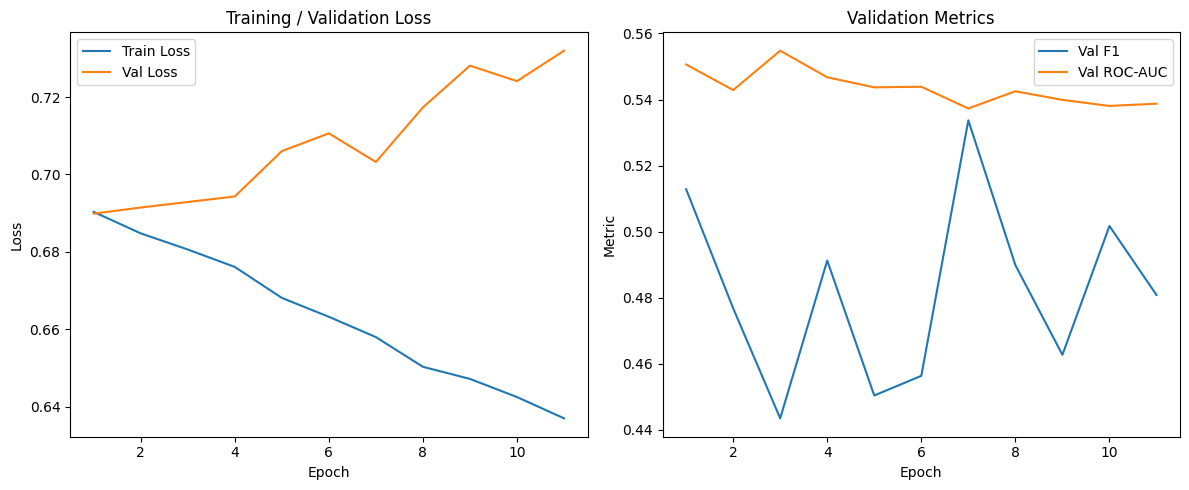

In [30]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["epoch"], history_df["val_f1"], label="Val F1")
plt.plot(history_df["epoch"], history_df["val_roc_auc"], label="Val ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Validation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
# Load best model for evaluation
best_epoch, best_val_loss, history = load_checkpoint(
    BEST_MODEL_PATH,
    model,
    optimizer=None,
    scheduler=None,
    device=device
)

print(f"Loaded best model from epoch {best_epoch}")
print(f"Best validation loss: {best_val_loss:.6f}")

Loaded best model from epoch 1
Best validation loss: 0.689863


In [32]:
#Test evaluation
@torch.no_grad()
def evaluate_test_set(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_probs = []
    all_targets = []

    for x_batch, y_batch in tqdm(loader, desc="Testing"):
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        logits = model(x_batch)
        loss = criterion(logits, y_batch)

        probs = torch.sigmoid(logits)

        running_loss += loss.item() * x_batch.size(0)

        all_probs.append(probs.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

    test_loss = running_loss / len(loader.dataset)

    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)

    metrics = compute_classification_metrics(all_targets, all_probs)

    metrics["loss"] = test_loss

    return metrics

In [33]:
#Run test evaluation
test_metrics = evaluate_test_set(
    model,
    test_loader,
    criterion,
    device
)

print("\nTEST RESULTS")
print("-" * 40)
print(f"Loss:      {test_metrics['loss']:.6f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1:        {test_metrics['f1']:.4f}")
print(f"ROC-AUC:   {test_metrics['roc_auc']:.4f}")

Testing: 100%|██████████| 183/183 [00:01<00:00, 116.23it/s]


TEST RESULTS
----------------------------------------
Loss:      0.692996
Accuracy:  0.5174
Precision: 0.5317
Recall:    0.4573
F1:        0.4917
ROC-AUC:   0.5277


In [34]:
#Collect test probabilities, predictions, and timestamps
@torch.no_grad()
def collect_test_predictions(model, loader, device):
    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []

    for x_batch, y_batch in tqdm(loader, desc="Collecting test predictions"):
        x_batch = x_batch.to(device, non_blocking=True)
        logits = model(x_batch)
        probs = torch.sigmoid(logits)

        preds = (probs >= 0.5).long()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.numpy())

    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    return all_probs, all_preds, all_targets


In [35]:
#Build a test predictions Dataframe
test_probs, test_preds, test_targets = collect_test_predictions(model, test_loader, device)

df_test_pred = pd.DataFrame({
    "end_time": pd.to_datetime(test_time),
    "y_true": test_targets.astype(int),
    "prob_up": test_probs,
    "prob_down": 1.0 - test_probs,
    "pred_label": test_preds.astype(int),
})

df_test_pred["correct"] = (df_test_pred["pred_label"] == df_test_pred["y_true"]).astype(int)
df_test_pred["confidence"] = np.maximum(df_test_pred["prob_up"], df_test_pred["prob_down"])

df_test_pred.head()

,end_time,y_true,prob_up,prob_down,pred_label,correct,confidence
0,2025-01-01 23:45:00,1,0.535067,0.464933,1,1,0.535067
1,2025-01-02 00:00:00,1,0.509102,0.490898,1,1,0.509102
2,2025-01-02 01:30:00,1,0.488102,0.511898,0,0,0.511898
3,2025-01-02 01:45:00,1,0.515313,0.484687,1,1,0.515313
4,2025-01-02 02:00:00,1,0.487753,0.512247,0,0,0.512247


In [36]:
#Define strong/weak zones
def assign_signal_zone(prob_up):
    if prob_up >= 0.7:
        return "strong_up"
    elif prob_up <= 0.3:
        return "strong_down"
    else:
        return "uncertain"

df_test_pred["signal_zone"] = df_test_pred["prob_up"].apply(assign_signal_zone)

df_test_pred["signal_zone"].value_counts()

,count
signal_zone,
uncertain,23362
strong_down,8
strong_up,1


In [37]:
#Summary by zone
zone_summary = (
    df_test_pred
    .groupby("signal_zone")
    .agg(
        samples=("y_true", "size"),
        accuracy=("correct", "mean"),
        avg_prob_up=("prob_up", "mean"),
        true_up_rate=("y_true", "mean"),
    )
    .sort_values("samples", ascending=False)
)

zone_summary

,samples,accuracy,avg_prob_up,true_up_rate
signal_zone,,,,
uncertain,23362,0.517464,0.493770,0.510316
strong_down,8,0.125000,0.268439,0.875000
strong_up,1,1.000000,0.731501,1.000000


In [38]:
#Separate evaluation for strong UP and strong down
strong_up_df = df_test_pred[df_test_pred["prob_up"] >= 0.7].copy()
strong_down_df = df_test_pred[df_test_pred["prob_up"] <= 0.3].copy()

print("STRONG UP SIGNALS")
print("-" * 40)
if len(strong_up_df) > 0:
    print("Samples:", len(strong_up_df))
    print("Accuracy:", strong_up_df["correct"].mean())
    print("Actual UP rate:", strong_up_df["y_true"].mean())
else:
    print("No strong_up samples found")

print("\nSTRONG DOWN SIGNALS")
print("-" * 40)
if len(strong_down_df) > 0:
    print("Samples:", len(strong_down_df))
    print("Accuracy:", strong_down_df["correct"].mean())
    print("Actual DOWN rate:", (1 - strong_down_df["y_true"]).mean())
else:
    print("No strong_down samples found")

STRONG UP SIGNALS
----------------------------------------
Samples: 1
Accuracy: 1.0
Actual UP rate: 1.0

STRONG DOWN SIGNALS
----------------------------------------
Samples: 8
Accuracy: 0.125
Actual DOWN rate: 0.125


In [39]:
df_test_pred["prob_bin"] = pd.cut(
    df_test_pred["prob_up"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

bin_summary = (
    df_test_pred
    .groupby("prob_bin", observed=False)
    .agg(
        samples=("y_true", "size"),
        avg_prob_up=("prob_up", "mean"),
        actual_up_rate=("y_true", "mean"),
        accuracy=("correct", "mean"),
    )
)

bin_summary

,samples,avg_prob_up,actual_up_rate,accuracy
prob_bin,,,,
"(-0.001, 0.1]",0,NaN,NaN,NaN
"(0.1, 0.2]",0,NaN,NaN,NaN
"(0.2, 0.3]",8,0.268439,0.875000,0.125000
"(0.3, 0.4]",266,0.377362,0.394737,0.605263
"(0.4, 0.5]",12837,0.464766,0.495677,0.504323
"(0.5, 0.6]",10111,0.531900,0.531303,0.531303
"(0.6, 0.7]",148,0.613797,0.554054,0.554054
"(0.7, 0.8]",1,0.731501,1.000000,1.000000
"(0.8, 0.9]",0,NaN,NaN,NaN


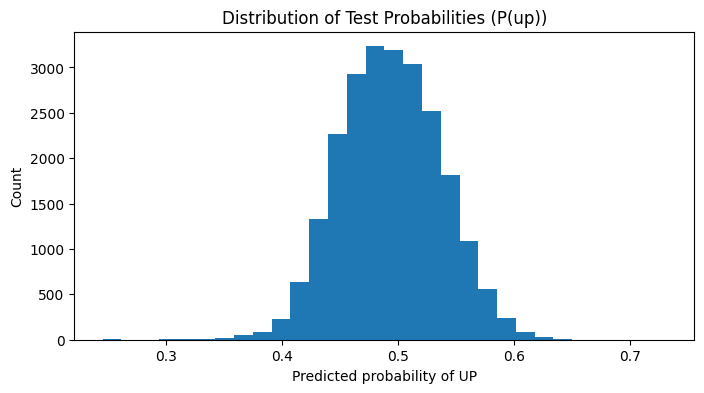

In [40]:
plt.figure(figsize=(8, 4))
plt.hist(df_test_pred["prob_up"], bins=30)
plt.title("Distribution of Test Probabilities (P(up))")
plt.xlabel("Predicted probability of UP")
plt.ylabel("Count")
plt.show()

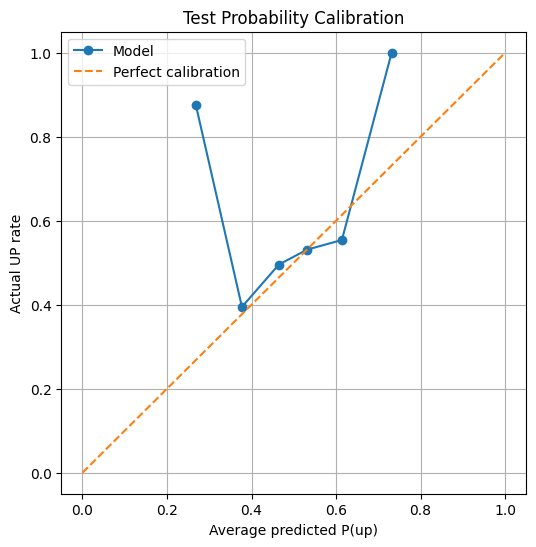

In [41]:
plot_df = bin_summary.dropna().copy()

plt.figure(figsize=(6, 6))
plt.plot(plot_df["avg_prob_up"], plot_df["actual_up_rate"], marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Average predicted P(up)")
plt.ylabel("Actual UP rate")
plt.title("Test Probability Calibration")
plt.legend()
plt.grid(True)
plt.show()